# 02 — Entraînement du réseau


In [6]:
import json

with open("params_simulation.json") as f:
    p = json.load(f)

L, Nx, Nt,t_end  = p["L"], p["Nx"], p["Nt"], p["t_end"]
AMPLITUDES    = p["AMPLITUDES"]
PULSATIONS    = p["PULSATIONS"]
n_sims        = p["n_sims"]

---
## 1. Paramètres

In [7]:
# Fichiers produits par le notebook 01
DATASET_FILE   = "wave_beam_dataset.csv"
NORMSTATS_FILE = "norm_stats.csv"

# Architecture du réseau
HIDDEN_SIZE = 256    # nombre de neurones par couche cachée
N_LAYERS    = 3     # nombre de couches cachées

# Entraînement
LEARNING_RATE = 1e-3
N_EPOCHS      = 10
BATCH_SIZE    = 512

---
## 2. Chargement des données

In [8]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Chargement du dataset et des stats de normalisation
df         = pd.read_csv(DATASET_FILE)
norm_stats = pd.read_csv(NORMSTATS_FILE, index_col=0)

#To check and visualise
print(f"Dataset : {len(df):,} lignes")
print(f"Splits  : {df['split'].value_counts().to_dict()}")

# Colonnes normalisées
INPUTS_N  = ["E_n", "rho_n", "L_n", "I_n", "omega_n", "A_force_n","x_n", "t_n"]
OUTPUTS_N = ["u_n"]

# Extraction train / val en utilisant la colonne split du dataset
train_mask = df["split"] == "train"
val_mask   = df["split"] == "val"

X_train = df.loc[train_mask, INPUTS_N].values.astype(np.float32)
y_train = df.loc[train_mask, OUTPUTS_N].values.astype(np.float32)

X_val   = df.loc[val_mask, INPUTS_N].values.astype(np.float32)
y_val   = df.loc[val_mask, OUTPUTS_N].values.astype(np.float32)

print(f"\nTrain : {len(X_train):,} exemples")
print(f"Val   : {len(X_val):,} exemples")

# Conversion en tenseurs PyTorch et création des DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE
)

Dataset : 2,500,000 lignes
Splits  : {'train': 1700000, 'test': 500000, 'val': 300000}

Train : 1,700,000 exemples
Val   : 300,000 exemples


---
## 3. Network defintion


In [9]:
class Reseau(nn.Module):

    def __init__(self, n_inputs, n_outputs, hidden_size, n_layers):
        super().__init__()

        couches = []
        taille_entree = n_inputs

        for _ in range(n_layers):
            couches.append(nn.Linear(taille_entree, hidden_size))  # couche linéaire
            couches.append(nn.Tanh())                              # activation non-linéaire
            taille_entree = hidden_size

        couches.append(nn.Linear(hidden_size, n_outputs))  # couche de sortie

        self.reseau = nn.Sequential(*couches)

    def forward(self, x):
        return self.reseau(x)


modele = Reseau(
    n_inputs    = len(INPUTS_N), 
    n_outputs   = len(OUTPUTS_N),   
    hidden_size = HIDDEN_SIZE,
    n_layers    = N_LAYERS,
)

n_params = sum(p.numel() for p in modele.parameters())
print(modele)
print(f"\nNombre de paramètres : {n_params:,}")

Reseau(
  (reseau): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): Tanh()
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)

Nombre de paramètres : 134,145


---
## 4. Training

In [10]:
criterion  = nn.MSELoss()   # erreur quadratique moyenne
optimiseur = torch.optim.Adam(modele.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiseur, mode="min", factor=0.5, patience=10
)

historique_train = []
historique_val   = []

meilleure_val = float("inf")   # on initialise au pire score possible
patience_compteur = 0          # on verra ça après

for epoch in range(1, N_EPOCHS + 1):

    # Phase entraînement
    modele.train()
    perte_train = 0.0       #initialisation of training loss
    for X_batch, y_batch in train_loader:
        optimiseur.zero_grad()                       # remet les gradients à zéro
        prediction = modele(X_batch)                 # prédiction
        perte      = criterion(prediction, y_batch)  # erreur
        perte.backward()                             # rétropropagation
        optimiseur.step()                            # mise à jour des poids
        perte_train += perte.item()
    perte_train /= len(train_loader)

    # Phase validation : un seul forward pass sur tout le val
    modele.eval()
    with torch.no_grad():
        pred_val = modele(torch.tensor(X_val)).numpy()

    # Loss globale 
    perte_val = ((pred_val - y_val)**2).mean()
    scheduler.step(perte_val)

    # Loss par output
    historique_train.append(perte_train)
    historique_val  .append(perte_val)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:4d}/{N_EPOCHS}  —  "
            f"train: {perte_train:.4f}  |  "
            f"val: {perte_val:.4f}  ")
    
    # Si la val s'est améliorée, on sauvegarde ce modèle
    if perte_val < meilleure_val:
        meilleure_val = perte_val
        torch.save(modele.state_dict(), "model.pth")   # on écrase avec le meilleur

# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historique_train, label="Train")
ax.plot(historique_val,   label="Validation")
ax.set_xlabel("Epoch") ; ax.set_ylabel("Erreur MSE")
ax.set_title("Courbe d'apprentissage")
ax.set_yscale("log")
ax.legend() ; ax.grid(True)
plt.tight_layout() ; plt.show()

# On recharge le meilleur modèle trouvé pendant l'entraînement
modele.load_state_dict(torch.load("model.pth",weights_only=True ))
print(f"Meilleur modèle rechargé — val minimale : {meilleure_val:.6f}")

Epoch    2/10  —  train: 1.0000  |  val: 1.8901  


KeyboardInterrupt: 

---
## 5. Vérification : prédiction d'un seul pas de temps

On prend des exemples du val set, on demande au réseau de prédire les incréments,
et on compare avec les vrais incréments.

Si les points sont bien alignés sur la diagonale rouge, le réseau prédit bien un pas de temps.

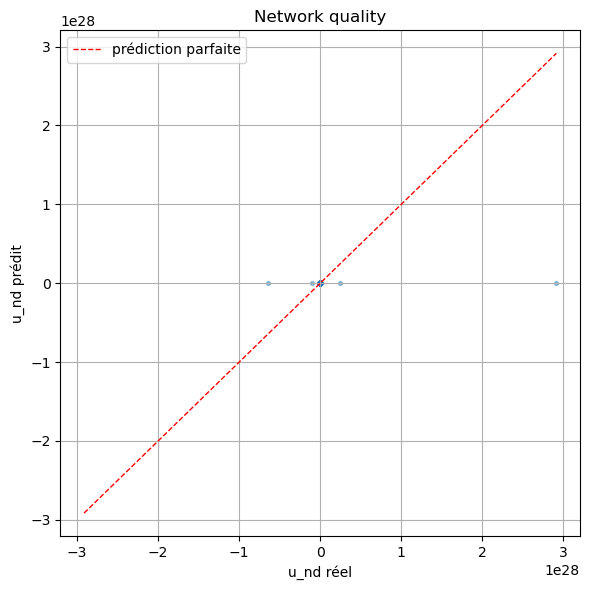

MSE : 4.4875e+54   |   R² : -0.0034


In [ ]:
# On met le réseau en mode évaluation (désactive le dropout si on en avait)
# En mode eval, les poids sont figés — le réseau ne s'entraîne plus
modele.eval()

# --- Sélection de 200 exemples aléatoires dans le val set ---
# On ne teste pas sur tout le val set pour aller plus vite
# replace=False = pas de doublon dans la sélection
idx    = np.random.choice(len(X_val), 200, replace=False)

# On récupère les inputs et les vrais outputs correspondants
# X_val[idx] sélectionne les 200 lignes choisies (inputs normalisés)
# y_val[idx] sélectionne les 200 vrais outputs correspondants (normalisés)
X_test = torch.tensor(X_val[idx])   # conversion en tenseur PyTorch pour le réseau
y_test = y_val[idx]                 # on garde en numpy, juste pour comparer après

# --- Prédiction du réseau ---
# torch.no_grad() : on dit à PyTorch de ne pas calculer les gradients
# inutile ici (pas d'entraînement), ça économise de la mémoire et va plus vite
with torch.no_grad():
    y_pred_n = modele(X_test).numpy()   # shape (200, 2) — 2 outputs : delta_u et delta_u_dot
                                        # les valeurs sont encore normalisées (z-score)

# --- Dénormalisation ---
mean_u, std_u = norm_stats.loc["u_nd", "mean"], norm_stats.loc ["u_nd","std"]
u_pred = y_pred_n[:,0] * std_u + mean_u
u_reel = y_test[:,0] * std_u + mean_u

# --- Graphiques "valeur prédite vs valeur réelle" ---
fig, ax = plt.subplots(figsize=(6, 6)) 

ax.scatter(u_reel, u_pred, alpha=0.4, s=8)
# Ligne rouge diagonale = prédiction parfaite
# Si le réseau était parfait, tous les points seraient sur cette ligne
lim = max(abs(u_reel).max(), abs(u_pred).max())   # échelle symétrique autour de 0

ax.plot([-lim, lim], [-lim, lim], "r--", lw=1, label="prédiction parfaite")

ax.set_xlabel("u_nd réel")
ax.set_ylabel("u_nd prédit")
ax.set_title("Network quality")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


# Métriques utiles
mse = ((u_pred - u_reel)**2).mean()
r2  = 1 - mse / u_reel.var()
print(f"MSE : {mse:.4e}   |   R² : {r2:.4f}")

In [ ]:
# ============================================================
# Comparaison trajectoire réelle vs prédite — cas INÉDIT
# Choisis un (A, ω) qui n'est PAS dans ton dataset d'entraînement
#========================================================

import random 

#A_test     = round(random.uniform(0.005,1),3)
#omega_test = round(random.uniform(10,90),1)

A_test     = 0.105/2
omega_test = 50

x_choisi   = 0.1     # point de la poutre à observer

### --- Étape 1 : simulation de référence avec ce nouveau (A, ω) ---
x_nodes = np.linspace(0, L, Nx)
dx = x_nodes[1] - x_nodes[0]
dt = t_end / Nt
CFL = v * dt / dx

u_prev = np.zeros(Nx)
u_curr = np.zeros(Nx)
ref_u    = []
ref_udot = []
ref_t    = []

for n in range(1, Nt - 1):
    tn = n * dt
    u_next = np.empty(Nx)
    u_next[1:-1] = (
        2.0 * u_curr[1:-1] - u_prev[1:-1]
        + CFL**2 * (u_curr[2:] - 2.0*u_curr[1:-1] + u_curr[:-2])
    )
    u_next[0]  = 0.0
    u_next[-1] = u_next[-2] + dx * A_test * np.sin(omega_test * tn)

    if n % T_SUB == 0:
        u_dot = (u_next - u_prev) / (2.0 * dt)
        ref_u   .append(u_curr.copy())
        ref_udot.append(u_dot .copy())
        ref_t.append((n - 1) * dt)


    u_prev = u_curr
    u_curr = u_next

# Trouver le nœud le plus proche de x_choisi
x_int    = x_nodes[1:-1]   # points intérieurs
idx_x    = np.argmin(np.abs(x_int - x_choisi))

# Extraire la trajectoire réelle en ce point
traj_reel = [ref_u[i][idx_x] for i in range(len(ref_u))]


### --- Étape 2 : rollouts du réseau (deux méthodes en parallèle) ---
dt_save = T_SUB * dt

# État initial commun aux deux méthodes
u_taylor   = ref_u[0][idx_x]   # méthode 1 : Taylor avec u_dot et u_xx
u_delta    = ref_u[0][idx_x]   # méthode 2 : delta_u directement
t_taylor   = ref_t[0]
t_delta    = ref_t[0]

traj_taylor = [u_taylor]
traj_delta  = [u_delta]

modele.eval()

def predire(u_val, t_val):
    """Forward pass du réseau pour un (u, t) donné. Renvoie (u_dot, u_xx, delta_u) en physique."""
    sin_wt_val = np.sin(omega_test * t_val)
    cos_wt_val = np.cos(omega_test * t_val)

    inp = np.array([[u_val, x_int[idx_x], A_test, omega_test,
                     t_val, sin_wt_val, cos_wt_val]], dtype=np.float32)

    # Normalisation (même ordre que pour l'entraînement)
    for k, col in enumerate(["u", "x", "A", "omega", "t", "sin_wt", "cos_wt"]):
        inp[0, k] = (inp[0, k] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

    with torch.no_grad():
        pred_n = modele(torch.tensor(inp)).numpy()[0]

    # Dénormalisation des trois sorties
    u_dot_pred   = pred_n[0] * norm_stats.loc["u_dot",   "std"] + norm_stats.loc["u_dot",   "mean"]
    u_xx_pred    = pred_n[1] * norm_stats.loc["u_xx",    "std"] + norm_stats.loc["u_xx",    "mean"]
    delta_u_pred = pred_n[2] * norm_stats.loc["delta_u", "std"] + norm_stats.loc["delta_u", "mean"]
    return u_dot_pred, u_xx_pred, delta_u_pred

for i in range(len(ref_u) - 1):

    # --- Méthode 1 : Taylor d'ordre 2 (u_dot et u_xx) ---
    u_dot_p, u_xx_p, _ = predire(u_taylor, t_taylor)
    u_taylor = u_taylor + dt_save * u_dot_p + 0.5 * dt_save**2 * v**2 * u_xx_p
    t_taylor = t_taylor + dt_save
    traj_taylor.append(u_taylor)

    # --- Méthode 2 : delta_u direct ---
    _, _, delta_u_p = predire(u_delta, t_delta)
    u_delta = u_delta + delta_u_p
    t_delta = t_delta + dt_save
    traj_delta.append(u_delta)

# --- Étape 3 : graphique ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(traj_reel,   label="Référence (simulation)",          color="steelblue", lw=2)
ax.plot(traj_taylor, label="Réseau — Taylor (u_dot + u_xx)",  color="orange",    lw=1.5, ls="--")
ax.plot(traj_delta,  label="Réseau — delta_u direct",         color="green",     lw=1.5, ls=":")
ax.set_xlabel("Numéro de snapshot")
ax.set_ylabel("u [m]")
ax.set_title(f"Cas — A={A_test}, ω={omega_test}, x≈{x_int[idx_x]:.2f} m")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Erreurs relatives moyennes
def err_rel(traj_pred):
    return np.mean(np.abs(np.array(traj_reel) - np.array(traj_pred))) \
           / (np.mean(np.abs(traj_reel)) + 1e-12)

print(f"Erreur relative — Taylor      : {err_rel(traj_taylor):.4e}")
print(f"Erreur relative — delta_u     : {err_rel(traj_delta):.4e}")

NameError: name 'v' is not defined

In [ ]:
# ============================================================
# Récapitulatif de la simulation et de l'entraînement
# ============================================================

print("=" * 50)
print("PARAMÈTRES DE LA SIMULATION")
print("=" * 50)
print(f"  Longueur de la poutre    : {L} m")
print(f"  Vitesse des ondes        : {v} m/s")
print(f"  Points en espace (Nx)    : {Nx}")
print(f"  Pas de temps internes    : {Nt}")
print(f"  Durée de simulation      : {t_end} s")
print(f"  Sous-échantillonnage     : 1 snapshot sur {T_SUB}")
print(f"  Δt entre snapshots       : {T_SUB * t_end / Nt:.5f} s")
print(f"  Amplitudes testées       : {AMPLITUDES}")
print(f"  Pulsations testées       : {PULSATIONS}")
print(f"  Nombre de simulations    : {len(AMPLITUDES)} × {len(PULSATIONS)} = {n_sims}")

print()
print("=" * 50)
print("PARAMÈTRES DU RÉSEAU")
print("=" * 50)
print(f"  Couches cachées          : {N_LAYERS}")
print(f"  Neurones par couche      : {HIDDEN_SIZE}")
print(f"  Nombre de paramètres     : {n_params:,}")
print(f"  Activation               : ReLU")

print()
print("=" * 50)
print("PARAMÈTRES D'ENTRAÎNEMENT")
print("=" * 50)
print(f"  Epochs                   : {N_EPOCHS}")
print(f"  Batch size               : {BATCH_SIZE}")
print(f"  Learning rate            : {LEARNING_RATE}")
print(f"  Erreur train finale      : {historique_train[-1]:.6f}")
print(f"  Erreur val finale        : {historique_val[-1]:.6f}")
print(f"  Erreur val minimale      : {min(historique_val):.6f} (epoch {historique_val.index(min(historique_val))+1})")

print()
print("=" * 50)
print("DATASET")
print("=" * 50)
print(f"  Lignes totales           : {len(df):,}")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s}                    : {n:,} lignes ({100*n/len(df):.1f} %)")

PARAMÈTRES DE LA SIMULATION
  Longueur de la poutre    : 1.0 m
  Vitesse des ondes        : 1.0 m/s
  Points en espace (Nx)    : 100
  Pas de temps internes    : 3000
  Durée de simulation      : 5.0 s
  Sous-échantillonnage     : 1 snapshot sur 5
  Δt entre snapshots       : 0.00833 s
  Amplitudes testées       : [0.079, 0.047, 0.087, 0.071, 0.014, 0.098, 0.077, 0.08]
  Pulsations testées       : [20.2, 46.0, 39.7, 84.1, 61.5, 75.8, 45.5, 28.2]
  Nombre de simulations    : 8 × 8 = 64

PARAMÈTRES DU RÉSEAU
  Couches cachées          : 4
  Neurones par couche      : 256
  Nombre de paramètres     : 200,195
  Activation               : ReLU

PARAMÈTRES D'ENTRAÎNEMENT
  Epochs                   : 110
  Batch size               : 512
  Learning rate            : 0.001
  Erreur train finale      : 0.011672
  Erreur val finale        : 0.023471
  Erreur val minimale      : 0.023471 (epoch 110)

DATASET
  Lignes totales           : 3,750,656
  train                    : 2,578,576 lignes (68.8